In [1]:
# !git clone https://github.com/microsoft/MS-SNSD

In [1]:
import os
import IPython.display as ipd
from tqdm import tqdm
import torch
import torchaudio
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

In [2]:
CLEAN_TRAIN_DIR = "MS-SNSD/clean_train"
CLEAN_TEST_DIR = "MS-SNSD/clean_test"
NOISE_TRAIN_DIR = "MS-SNSD/noise_train"
NOISE_TEST_DIR = "MS-SNSD/noise_test"

SAMPLE_RATE = 16000
DURATION = 3
AUDIO_LENGTH = SAMPLE_RATE * DURATION

In [3]:
def audio_paths(dir: str) -> list[str]:
    return [os.path.join(dir, fname) for fname in os.listdir(dir) if fname.endswith(".wav")]

train_clean_paths = audio_paths(CLEAN_TRAIN_DIR)
train_noise_paths = audio_paths(NOISE_TRAIN_DIR)
test_clean_paths = audio_paths(CLEAN_TEST_DIR)
test_noise_paths = audio_paths(NOISE_TEST_DIR)

print(f"Train clean files: {len(train_clean_paths)}")
print(f"Train noise files: {len(train_noise_paths)}")
print(f"Test clean files: {len(test_clean_paths)}")
print(f"Test noise files: {len(test_noise_paths)}")

Train clean files: 23075
Train noise files: 128
Test clean files: 1100
Test noise files: 51


In [5]:
ipd.Audio(train_clean_paths[0])

In [6]:
ipd.Audio(train_noise_paths[0])

In [4]:
def snr_mixer(clean: torch.Tensor, noise: torch.Tensor, snr_db: float) -> torch.Tensor:
    clean_rms = torch.sqrt(torch.mean(clean**2))
    noise_rms = torch.sqrt(torch.mean(noise**2))

    snr = 10 ** (snr_db / 20)
    target_noise_rms = clean_rms / snr

    noise = noise * (target_noise_rms / noise_rms)
    return clean + noise

def process_wav_len(wav: torch.Tensor, audio_length: int) -> torch.Tensor:
    if wav.size(1) > audio_length:
        wav = wav[:, :audio_length]
    else:
        padding = audio_length - wav.size(1)
        wav = F.pad(wav, (0, padding))
    return wav

In [5]:
clean, _ = torchaudio.load(train_clean_paths[0])
noise, _ = torchaudio.load(train_noise_paths[0])

clean = process_wav_len(clean, AUDIO_LENGTH)
noise = process_wav_len(noise, AUDIO_LENGTH)
noisy = snr_mixer(clean, noise, snr_db=10)
ipd.Audio(noisy, rate=SAMPLE_RATE)

In [6]:
class SpeechDataset(Dataset):
    def __init__(self, clean_paths: list[str], noise_paths: list[str], audio_len: int = AUDIO_LENGTH, sample_rate: int = SAMPLE_RATE) -> None:
        self._clean_paths = clean_paths
        self._noise_paths = noise_paths
        self._audio_len = audio_len
        self._mel_transform = torchaudio.transforms.MelSpectrogram(
            sample_rate=sample_rate,
            n_fft=1024,
            hop_length=128,
            n_mels=80,
        )
        self._amplitude_to_db = torchaudio.transforms.AmplitudeToDB()

    def __len__(self):
        return len(self._clean_paths)

    def __getitem__(self, idx: int) -> tuple[torch.Tensor, torch.Tensor]:
        clean_path = self._clean_paths[idx]
        noise_path = np.random.choice(self._noise_paths)

        clean_waveform, _ = torchaudio.load(clean_path)
        noise_waveform, _ = torchaudio.load(noise_path)

        clean_waveform = self._process_wav_len(clean_waveform)
        noise_waveform = self._process_wav_len(noise_waveform)

        snr_db = np.random.uniform(-5, 20)
        noisy_waveform = snr_mixer(clean_waveform, noise_waveform, snr_db)
        
        clean_mel = self._mel_transform(clean_waveform)
        clean_mel = self._amplitude_to_db(clean_mel)
        noisy_mel = self._mel_transform(noisy_waveform)
        noisy_mel = self._amplitude_to_db(noisy_mel)

        return {
            "noisy_mel": noisy_mel,
            "clean_mel": clean_mel,
            "noisy_wav": noisy_waveform,
            "clean_wav": clean_waveform,
            "snr": snr_db,
        }

    def _process_wav_len(self, wav: torch.Tensor) -> torch.Tensor:
        if wav.size(1) > self._audio_len:
            wav = wav[:, :self._audio_len]
        else:
            padding = self._audio_len - wav.size(1)
            wav = F.pad(wav, (0, padding))
        return wav

SNR: -2.52 dB
Noisy mel shape: torch.Size([80, 376])


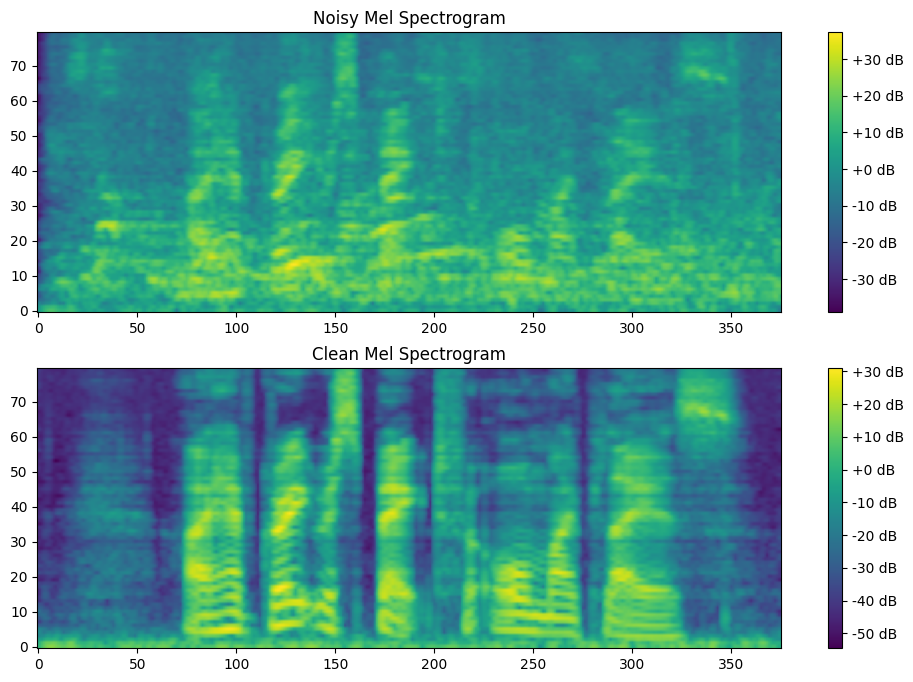

In [7]:
train_dataset = SpeechDataset(train_clean_paths, train_noise_paths)
test_dataset = SpeechDataset(test_clean_paths, test_noise_paths)

item = train_dataset[10]

noisy_mel = item["noisy_mel"].squeeze(0)
clean_mel = item["clean_mel"].squeeze(0)
snr = item["snr"]

print(f"SNR: {snr:.2f} dB")
print(f"Noisy mel shape: {noisy_mel.shape}")

plt.figure(figsize=(12, 8))
plt.subplot(2, 1, 1)
plt.title("Noisy Mel Spectrogram")
plt.imshow(noisy_mel.numpy(), aspect="auto", origin="lower")
plt.colorbar(format="%+2.0f dB")

plt.subplot(2, 1, 2)
plt.title("Clean Mel Spectrogram")
plt.imshow(clean_mel.numpy(), aspect="auto", origin="lower")
plt.colorbar(format="%+2.0f dB")
plt.show()

In [9]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, kernel_size: int =3):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size, padding=kernel_size//2)
        self.relu = nn.ReLU()
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size, padding=kernel_size//2)
        self.ln1 = nn.GroupNorm(1, out_channels)
        self.ln2 = nn.GroupNorm(1, out_channels)
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.conv1(x)
        x = self.ln1(x)
        x = self.relu(x)
        x = self.conv2(x)
        x = self.ln2(x)
        return x

class EncoderBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, pool_size: int =2):
        super().__init__()
        self.conv_block = ConvBlock(in_channels, out_channels)
        self.pool = nn.MaxPool2d(pool_size)
    
    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        x = self.conv_block(x)
        return self.pool(x), x

class DecoderBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, kernel_size: int =2, stride: int =2, upsample: bool =True):
        super().__init__()
        self.upsample = nn.ConvTranspose2d(out_channels, out_channels//2, kernel_size, stride) if upsample else nn.Identity()
        self.conv_block = ConvBlock(in_channels, out_channels)
    
    def forward(self, x: torch.Tensor, skip_connection: torch.Tensor) -> torch.Tensor:
        x = self._concat(x, skip_connection)
        x = self.conv_block(x)
        x = self.upsample(x)
        return x

    def _concat(self, x: torch.Tensor, skip_connection: torch.Tensor) -> torch.Tensor:
        _, _, h, w = x.size()
        skip_connection = transforms.CenterCrop((h, w))(skip_connection)
        return torch.cat((skip_connection, x), dim=1)

class Bottleneck(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.conv_block = ConvBlock(in_channels, out_channels)
        self.upsample = nn.ConvTranspose2d(out_channels, out_channels//2, kernel_size=2, stride=2)
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.conv_block(x)
        x = self.upsample(x)
        return x

class UNet(nn.Module):
    def __init__(self, in_channels: list[int], out_channels: list[int]) -> None:
        super().__init__()
        self.encoders = nn.ModuleList()
        self.decoders = nn.ModuleList()

        for i in range(1, len(in_channels)):
            self.encoders.append(EncoderBlock(in_channels[i-1], in_channels[i]))

        self.bottleneck = Bottleneck(in_channels[-1], out_channels[0])

        for i in range(1, len(out_channels)-1):
            self.decoders.append(DecoderBlock(out_channels[i-1], out_channels[i]))
        self.decoders.append(DecoderBlock(out_channels[-2], out_channels[-1], upsample=False))

        self.final_conv = nn.Conv2d(out_channels[-1], 1, kernel_size=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        skip_connections = []

        for encoder in self.encoders:
            x, skip_connection = encoder(x)
            skip_connections.append(skip_connection)

        x = self.bottleneck(x)

        skip_connections = skip_connections[::-1]
        for i, decoder in enumerate(self.decoders):
            x = decoder(x, skip_connections[i])

        x = self.final_conv(x)
        return x

In [10]:
input = torch.randn((1, 1, 80, 376))
model = UNet(in_channels=[1, 64, 128, 256], out_channels=[512, 256, 128, 64])
model(input).shape

torch.Size([1, 1, 80, 376])

In [33]:
from torch.utils.tensorboard import SummaryWriter

@torch.no_grad()
def eval_metrics(preds: torch.Tensor, targets: torch.Tensor) -> dict[str, float]:
    mse = F.mse_loss(preds, targets).item()
    mae = F.l1_loss(preds, targets).item()
    spec_converge = torch.norm(targets - preds, p="fro") / torch.norm(
        targets, p="fro"
    )
    return {"mse": mse, "mae": mae, "spec_converge": spec_converge.item()}

def eval_test(model: nn.Module, test_loader: DataLoader, criterion, device ="cuda"):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for batch in tqdm(test_loader):
            noisy_mel = batch["noisy_mel"].to(device)
            clean_mel = batch["clean_mel"].to(device)

            outputs = model(noisy_mel)
            loss = criterion(outputs, clean_mel)
            total_loss += loss.item()
    return total_loss / len(test_loader)

def train_loop(model: nn.Module, train_loader: DataLoader, test_loader: DataLoader, criterion, optimizer, num_epochs: int, device="cuda", log_step: int =10, eval_step: int =100):
    writer = SummaryWriter()
    global_step = 0
    model.to(device)

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")
        for i, batch in enumerate(pbar):
            noisy_mel = batch["noisy_mel"].to(device)
            clean_mel = batch["clean_mel"].to(device)

            optimizer.zero_grad()
            outputs = model(noisy_mel)
            loss = criterion(outputs, clean_mel)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

            if i % log_step == 0:
                metrics = eval_metrics(outputs, clean_mel)
                for key, value in metrics.items():
                    writer.add_scalar(f"Train/{key}", value, global_step)

                writer.add_scalar("Train/Loss", loss.item(), global_step)
                global_step += 1
                pbar.set_postfix({"loss": loss.item()})

            if i % eval_step == 0:
                test_loss = eval_test(model, test_loader, criterion, device)
                writer.add_scalar("Test/Loss", test_loss, global_step)

        train_loss /= len(train_loader)
        test_loss = eval_test(model, test_loader, criterion, device)

        writer.add_scalar("Train/EpochLoss", train_loss, epoch)
        writer.add_scalar("Test/EpochLoss", test_loss, epoch)
        print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}")

    writer.close()

In [35]:
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

model = UNet(in_channels=[1, 64, 128, 256], out_channels=[512, 256, 128, 64])
criterion = nn.L1Loss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

In [36]:
train_loop(model, train_loader, test_loader, criterion, optimizer, num_epochs=1, device="mps", log_step=10, eval_step=100)

100%|██████████| 69/69 [00:29<00:00,  2.35it/s]

Epoch [1/1], Train Loss: 13.1015, Test Loss: 10.5837


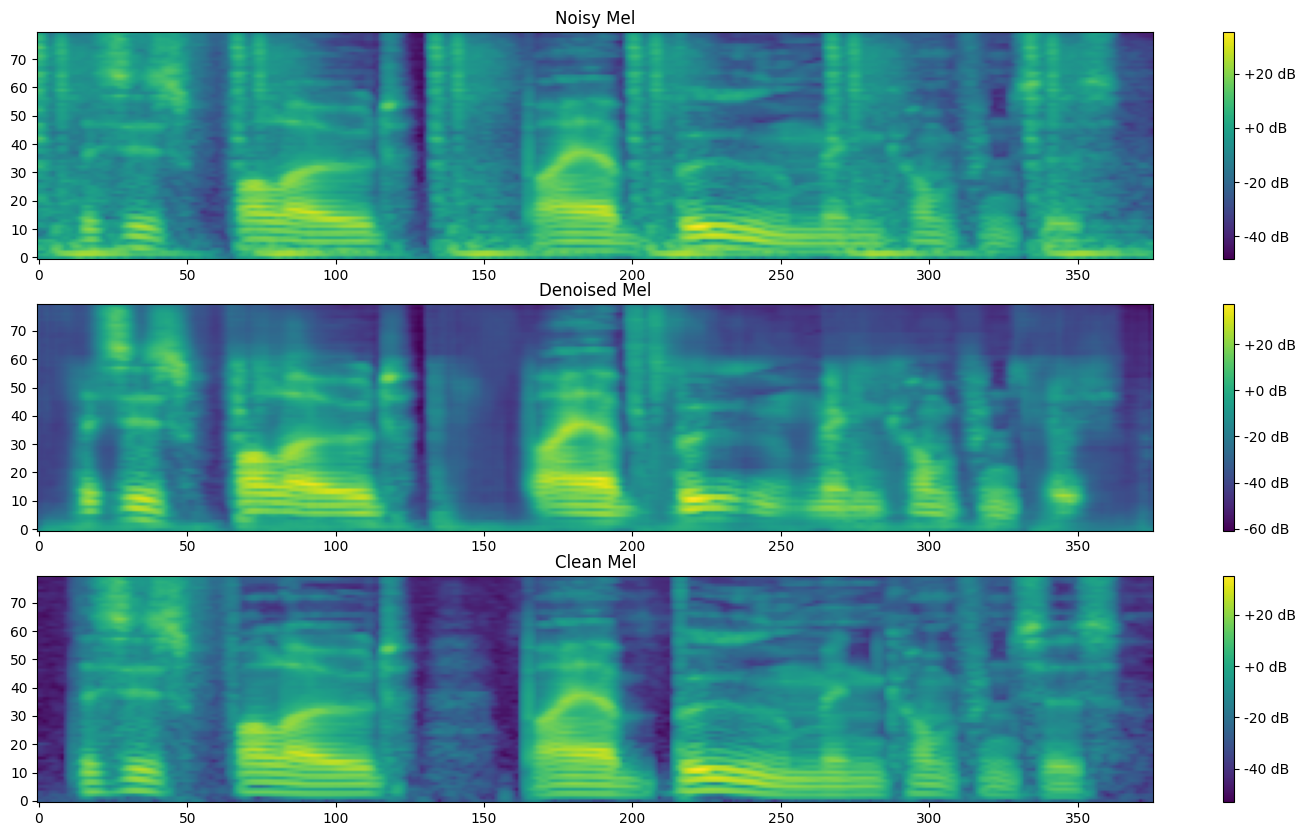

In [18]:
def plot_denoise(model, dataset, idx, device='mps'):
    model.eval()
    sample = dataset[idx]
    
    noisy_mel_input = sample['noisy_mel'].unsqueeze(0).to(device)
    clean_mel = sample['clean_mel'].squeeze(0)
    noisy_mel = sample['noisy_mel'].squeeze(0)
    
    with torch.no_grad():
        denoised_mel = model(noisy_mel_input).squeeze(0).squeeze(0).cpu()
        
    
    plt.figure(figsize=(18, 10))
    
    plt.subplot(3, 1, 1)
    plt.title(f"Noisy Mel")
    plt.imshow(noisy_mel.numpy(), aspect='auto', origin='lower')
    plt.colorbar(format='%+2.0f dB')
    
    plt.subplot(3, 1, 2)
    plt.title("Denoised Mel")
    plt.imshow(denoised_mel.numpy(), aspect='auto', origin='lower')
    plt.colorbar(format='%+2.0f dB')
    
    plt.subplot(3, 1, 3)
    plt.title("Clean Mel")
    plt.imshow(clean_mel.numpy(), aspect='auto', origin='lower')
    plt.colorbar(format='%+2.0f dB')
    
    plt.show()

plot_denoise(model, test_dataset, 1)

In [16]:
model = UNet(in_channels=[1, 64, 128, 256], out_channels=[512, 256, 128, 64])
model = model.to('mps')
model.load_state_dict(torch.load("unet_denoiser.pth"))
model.eval()

UNet(
  (encoders): ModuleList(
    (0): EncoderBlock(
      (conv_block): ConvBlock(
        (conv1): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (relu): ReLU()
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (ln1): GroupNorm(1, 64, eps=1e-05, affine=True)
        (ln2): GroupNorm(1, 64, eps=1e-05, affine=True)
      )
      (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): EncoderBlock(
      (conv_block): ConvBlock(
        (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (relu): ReLU()
        (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (ln1): GroupNorm(1, 128, eps=1e-05, affine=True)
        (ln2): GroupNorm(1, 128, eps=1e-05, affine=True)
      )
      (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (2): EncoderBlock(
      (conv_block): ConvB

In [ ]:
sample = test_dataset[1]

noisy_mel_input = sample['noisy_mel'].unsqueeze(0).to('mps')
clean_mel = sample['clean_mel'].squeeze(0)
noisy_mel = sample['noisy_mel'].squeeze(0)

with torch.no_grad():
    denoised_mel = model(noisy_mel_input).squeeze(0).squeeze(0).cpu()

griffin_lim = torchaudio.transforms.GriffinLim(
    n_fft=1024,
    hop_length=128,
)

inverse_mel_transform = torchaudio.transforms.InverseMelScale(
    n_stft=1024 // 2 + 1,
    n_mels=80,
    sample_rate=SAMPLE_RATE,
)

In [23]:
noisy_wav = griffin_lim(inverse_mel_transform(noisy_mel))
ipd.Audio(noisy_wav, rate=SAMPLE_RATE)

In [24]:
clean_wav = griffin_lim(inverse_mel_transform(clean_mel))
ipd.Audio(clean_wav, rate=SAMPLE_RATE)

In [25]:
denoised_wav = griffin_lim(inverse_mel_transform(denoised_mel))
ipd.Audio(denoised_wav, rate=SAMPLE_RATE)

In [26]:
torch.save(model, "nn_denoiser.pth")